# Ex1 - Eran Rehani 207823063

## Part A

**Calculate powers of golden mean backwards**

Define a function: `golden_powers_down(n, type)` that returns a numpy array of size `(n, 3)` and `dtype=type` (either `"float32"` or `"float64"`).

* The **first column** is the power calculated by the linear relation.
* The **second column** is the power calculated directly.
* The **third column** is the relative difference of the two.
* The first line is for $power=0$ and the last is for $n-1$.

**Tasks:**
1. Run the function for $n=31$ and `type='float32'`.
2. Plot the log of the absolute value of errors.

/tmp/ipykernel_164921/2456454305.py:38: RuntimeWarning: divide by zero encountered in log10
  plt.plot(range(2, 25), np.log10(abs(goldown[2:25, 2])))


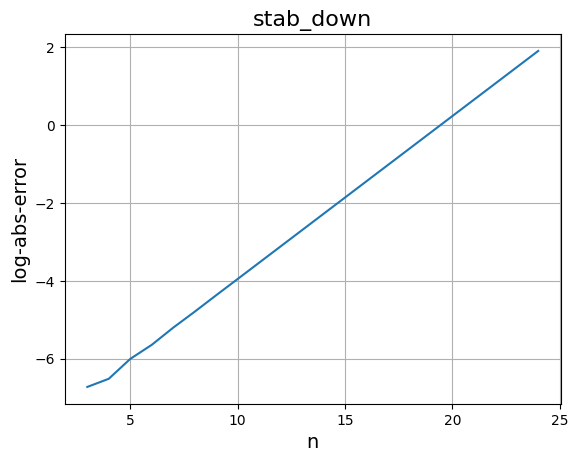

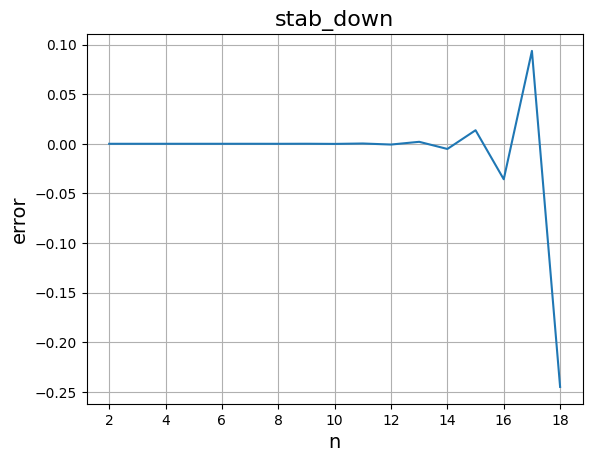

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def golden_powers_down(n, type):
    if type not in ['float32', 'float64']:
        raise ValueError("type must be 'float32' or 'float64'")
    
    dt = np.dtype(type)
    result = np.zeros((n, 3), dtype=dt)
    
    phi = dt.type((1.0 + np.sqrt(5.0)) / 2.0)
    
    result[0, 0] = dt.type(1.0)
    result[0, 1] = dt.type(1.0)
    result[0, 2] = dt.type(0.0)
    
    if n > 1:
        result[1, 0] = dt.type(1.0 / phi)
        result[1, 1] = dt.type(1.0 / phi)
        result[1, 2] = dt.type(0.0)
        
    for i in range(2, n):
        linear = dt.type(result[i-2, 0] - result[i-1, 0])   #g_n = g_{n-2} - g_{n-1}
        direct = dt.type(phi ** -i) #g_n = phi^{-n}
        rel_diff = dt.type((linear - direct) / direct) #relative difference
        
        result[i, 0] = linear
        result[i, 1] = direct
        result[i, 2] = rel_diff
        
    return result

#  Execution Block 
goldown = golden_powers_down(31, 'float32')

# First Plot: Logarithm of absolute value of errors
plt.figure()
plt.plot(range(2, 25), np.log10(abs(goldown[2:25, 2])))
plt.title('stab_down', fontsize=16)
plt.xlabel('n', fontsize=14)
plt.ylabel('log-abs-error', fontsize=14)
plt.grid()
plt.show()

# Second Plot: Raw errors
plt.figure()
plt.plot(range(2, 19), goldown[2:19, 2])
plt.title('stab_down', fontsize=16)
plt.xlabel('n', fontsize=14)
plt.ylabel('error', fontsize=14)
plt.grid()
plt.show()

The recursive formula $g_n = g_{n-2} - g_{n-1}$ is mathematically exact for calculating inverse golden ratio powers, but it is computationally unstable due to the exponentially growing complementary solution, $B(-\phi)^n$. 

While the true theoretical values shrink toward zero, microscopic floating-point rounding errors introduced at the very first step grow exponentially with every subsequent subtraction. Because the computer continuously subtracts two numbers that are getting smaller, the tiny underlying errors quickly overwhelm the actual calculation, amplifying by a factor of $\phi^2 \approx 2.618$ at each step.

* **Logarithmic Graph:** Illustrates this error multiplying at a constant, predictable rate, physically reflecting the $\approx 0.42$ logarithmic slope generated by the $\phi^2$ amplification per step.
* **Raw Error Graph:** Demonstrates the computed values violently oscillating between positive and negative numbers—driven directly by the negative base of the $(-\phi)^n$ error term—until they completely diverge from reality by step 15, rendering the recursive method entirely useless.

---
## Part B — Numerical Derivatives of sin(x)

Compare accuracy of three finite-difference formulations for $f'(x)$ :

| Method | Formula | Truncation Error |
|---|---|---|
| **2-point** | $\displaystyle\frac{f(x+dx) - f(x)}{dx}$ | $O(dx)$ |
| **3-point** | $\displaystyle\frac{f(x+dx) - f(x-dx)}{2\,dx}$ | $O(dx^2)$ |
| **5-point** | $\displaystyle\frac{-f(x+2dx)+8f(x+dx)-8f(x-dx)+f(x-2dx)}{12\,dx}$ | $O(dx^4)$ |

### Function Definitions
Write the following functions:
* `derivative2p(f, x, dx)`
* `derivative3p(f, x, dx)`
* `derivative5p(f, x, dx)`


In [12]:
import numpy as np

def func(x):
    return np.sin(x)

def true_deriv(x):
    return np.cos(x)

# Derivative functions 

def derivative2p(f, x, dx):
    """2-point forward difference: O(dx) accuracy."""
    return (f(x + dx) - f(x)) / dx

def derivative3p(f, x, dx):
    """3-point central difference: O(dx^2) accuracy."""
    return (f(x + dx) - f(x - dx)) / (2 * dx)

def derivative5p(f, x, dx):
    """5-point central difference: O(dx^4) accuracy."""
    return (-f(x + 2*dx) + 8*f(x + dx) - 8*f(x - dx) + f(x - 2*dx)) / (12 * dx)

#  Accuracy comparison for 10 random x values
np.random.seed(12345)
x = np.random.rand(10)
dx = 0.002

print('%12s %12s %12s %12s %12s ' % ('x', 'dfdx', 'err2p', 'err3p', 'err5p'))
for a in x:
    der2p = derivative2p(func, a, dx)
    der3p = derivative3p(func, a, dx)
    der5p = derivative5p(func, a, dx)
    der = true_deriv(a)
    print('%12.4e %12.4e %12.4e %12.4e %12.4e ' % (a, der, der2p/der-1, der3p/der-1, der5p/der-1))

           x         dfdx        err2p        err3p        err5p 
  9.2962e-01   5.9814e-01  -1.3405e-03  -6.6667e-07  -5.8287e-13 
  3.1638e-01   9.5037e-01  -3.2804e-04  -6.6667e-07  -5.3979e-13 
  1.8392e-01   9.8313e-01  -1.8669e-04  -6.6667e-07  -5.4456e-13 
  2.0456e-01   9.7915e-01  -2.0813e-04  -6.6667e-07  -5.3024e-13 
  5.6773e-01   8.4313e-01  -6.3843e-04  -6.6667e-07  -5.0382e-13 
  5.9554e-01   8.2784e-01  -6.7828e-04  -6.6667e-07  -5.1281e-13 
  9.6451e-01   5.6982e-01  -1.4428e-03  -6.6667e-07  -5.8087e-13 
  6.5318e-01   7.9416e-01  -7.6590e-04  -6.6667e-07  -5.2092e-13 
  7.4891e-01   7.3243e-01  -9.3022e-04  -6.6667e-07  -5.1659e-13 
  6.5357e-01   7.9392e-01  -7.6652e-04  -6.6667e-07  -5.4468e-13 


In [13]:
# --- Accuracy vs dx at x = 0.7 ---
a = 0.7
der = true_deriv(a)
print('%s %12.4e %s %12.4e ' % ('x=', a, 'dfdx=', der))
print('%12s %12s %12s %12s ' % ('dx', 'err2p', 'err3p', 'err5p'))

dx = 0.1
for _ in range(10):
    der2p = derivative2p(func, a, dx)
    der3p = derivative3p(func, a, dx)
    der5p = derivative5p(func, a, dx)
    print('%12.4e %12.4e %12.4e %12.4e ' % (dx, der2p/der-1, der3p/der-1, der5p/der-1))
    dx *= 0.1

x=   7.0000e-01 dfdx=   7.6484e-01 
          dx        err2p        err3p        err5p 
  1.0000e-01  -4.3745e-02  -1.6658e-03  -3.3294e-06 
  1.0000e-02  -4.2281e-03  -1.6667e-05  -3.3333e-10 
  1.0000e-03  -4.2131e-04  -1.6667e-07  -5.8065e-14 
  1.0000e-04  -4.2116e-05  -1.6669e-09  -4.8150e-13 
  1.0000e-05  -4.2115e-06  -2.2255e-11  -5.3202e-12 
  1.0000e-06  -4.2114e-07   2.8550e-11   6.4839e-11 
  1.0000e-07  -4.1994e-08   1.0113e-10   1.0113e-10 
  1.0000e-08   3.0043e-09   3.0043e-09   1.7946e-09 
  1.0000e-09   3.0043e-09   3.0043e-09   5.1390e-08 
  1.0000e-10   5.8363e-07   5.8363e-07   9.4653e-07 


### Finite Difference Formulas Derivation

All three formulas are derived from **Taylor expansion** of $f$ around $x$:
$$f(x \pm h) = f(x) \pm h f'(x) + \frac{h^2}{2}f''(x) \pm \frac{h^3}{6}f'''(x) + \frac{h^4}{24}f^{(4)}(x) \pm \cdots$$

- **2-point:** $\frac{f(x+h)-f(x)}{h} = f'(x) - \frac{h}{2}f''(x) + O(h^2)$ → error $\approx -\frac{h}{2}f''(x)$, i.e. $O(h)$

- **3-point:** $\frac{f(x+h)-f(x-h)}{2h} = f'(x) - \frac{h^2}{6}f'''(x) + O(h^4)$ → error $\approx -\frac{h^2}{6}f'''(x)$, i.e. $O(h^2)$. The even-order terms cancel by symmetry.

- **5-point:** Combining 4 evaluations to cancel both $h^2$ and $h^4$ terms gives:
$$\frac{-f(x+2h)+8f(x+h)-8f(x-h)+f(x-2h)}{12h} = f'(x) - \frac{h^4}{30}f^{(5)}(x) + O(h^6)$$
  → error $\approx -\frac{h^4}{30}f^{(5)}(x)$, i.e. $O(h^4)$.

For $f(x) = \sin(x)$, derivatives cycle: $f'=\cos x$, $f''=-\sin x$, $f'''=-\cos x$, $f^{(5)}=\cos x$.

Dividing truncation error by $f'(x)$ to get **relative error**:

$$\text{rel. err}_{3p} = -\frac{h^2}{6}\cdot\frac{f'''(x)}{f'(x)} = -\frac{h^2}{6}\cdot\frac{-\cos x}{\cos x} = +\frac{h^2}{6}$$

$$\text{rel. err}_{5p} = -\frac{h^4}{30}\cdot\frac{f^{(5)}(x)}{f'(x)} = -\frac{h^4}{30}\cdot\frac{\cos x}{\cos x} = -\frac{h^4}{30}$$

Both are **independent of x**, which is why all 10 rows show the same `err3p` and `err5p`:

| Method | Formula | Value at $dx=0.002$ |
|---|---|---|
| 3-point | $+dx^2/6$ | $+6.667\times 10^{-7}$ |
| 5-point | $-dx^4/30$ | $-5.4468\times 10^{-13}$ |

The 2-point error $-\frac{h}{2}\tan(x)$ **does** vary with $x$, as seen in the table.

### Error Analysis ###

Two sources of error compete as $dx$ decreases:

1. **Truncation error** — decreases with smaller $dx$ (theory)
2. **Round-off error** — increases with smaller $dx$ because of finite precision. The difference $f(x+dx)-f(x)$ becomes very small, and dividing by $dx$ amplifies any tiny rounding errors in the numerator.

| Method | Truncation | Round-off | Optimal $dx$ | Observed minimum |
|---|---|---|---|---|
| 2-point | $\sim dx$ | $\sim \varepsilon/dx$ | $\sqrt{2\varepsilon} \approx 2.6\times10^{-8}$ | between $10^{-7}$ and $10^{-8}$ |
| 3-point | $\sim dx^2$ | $\sim \varepsilon/dx$ | $(3\varepsilon)^{1/3} \approx 9.5\times10^{-6}$ | between $10^{-5}$ and $10^{-6}$ |
| 5-point | $\sim dx^4$ | $\sim \varepsilon/dx$ | $(45\varepsilon/4)^{1/5} \approx 1.3\times10^{-3}$ | between $10^{-3}$ and $10^{-4}$ |

where $\varepsilon \approx 2.22\times10^{-16}$ is the float64 machine epsilon.